# 🤖 Fase 4: Modelagem e Clusterização Agrícola do Paraná

Este notebook serve como o **roadmap passo a passo** para o pipeline de modelagem não supervisionada. 
Aqui, consolidamos os dados de features temporais gerados na Fase 3 por município e executamos a segmentação isolada por grão (soja, milho e trigo) para a série histórica de 2010 a 2024.

### 🎯 Objetivos Analíticos:
1. **Importação e Preparação** da base de features Parquet.
2. **Análise de Multicolinearidade Completa** (correlação de todas as variáveis).
3. **Normalização Robusta** (`RobustScaler`) para blindagem contra outliers agrícolas (mega-produtores).
4. **Validação de K** via Elbow Method (Inércia) e Silhouette Score.
5. **Treinamento e Reordenação Consistente** de clusters com base na produção média.
6. **Perfilamento de Negócio** dos clusters gerados.
7. **Consolidação em Pipeline de Orquestração** de todas as culturas.

## ⚙️ Configuração do Ambiente e Imports

In [30]:
import sys
from pathlib import Path

# Adiciona o diretório raiz do projeto ao sys.path para imports absolutos do src
BASE_DIR = Path.cwd().parent
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Configurações de visualização
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
np.set_printoptions(suppress=True)

## 🛠️ Passo 1: Carregar Base de Features Consolidadas

Carregamos as features estáticas construídas no arquivo `pam_parana_features.parquet` gerado na Fase 3.

In [32]:
features_path = BASE_DIR / "data" / "processed" / "pam_parana_features.parquet"
df_features = pd.read_parquet(features_path)

print(f"Dimensões da base: {df_features.shape[0]} linhas (município-culturas) e {df_features.shape[1]} colunas.")
print("Culturas disponíveis:", df_features["produto"].unique().tolist())
print("Colunas do dataset:", df_features.columns.tolist())
df_features.head()

Dimensões da base: 1197 linhas (município-culturas) e 13 colunas.
Culturas disponíveis: ['milho', 'soja', 'trigo']
Colunas do dataset: ['municipio_codigo', 'municipio_nome', 'produto', 'prod_media', 'area_media', 'rendimento_medio_med', 'valor_producao_medio', 'volatilidade_prod', 'cagr_producao', 'cagr_rendimento', 'trend_slope_producao', 'market_share_medio', 'perda_area_media']


,municipio_codigo,municipio_nome,produto,prod_media,area_media,rendimento_medio_med,valor_producao_medio,volatilidade_prod,cagr_producao,cagr_rendimento,trend_slope_producao,market_share_medio,perda_area_media
0,4100103,Abatiá - PR,milho,21400.600000,4098.333333,5797.533333,14555.533333,0.805873,0.022440,-0.019616,1455.182143,1.336364e-03,0.0
1,4100103,Abatiá - PR,soja,28033.666667,9293.333333,2983.533333,42277.666667,0.292888,0.048450,0.023798,1447.800000,1.654275e-03,0.0
2,4100103,Abatiá - PR,trigo,6993.466667,3049.333333,1846.600000,5305.333333,0.763310,-0.025751,-0.007851,-246.053571,2.300003e-03,0.0
3,4100202,Adrianópolis - PR,milho,9004.400000,1723.000000,5837.000000,4922.200000,0.397340,-0.164221,0.027434,-652.728571,6.107541e-04,0.0
4,4100202,Adrianópolis - PR,soja,8.733333,2.533333,459.266667,22.533333,2.646170,-0.128571,-0.031714,3.025000,4.341073e-07,0.0


## 📐 Passo 2: Análise de Correlação e Multicolinearidade Completa

Para obter uma visão holística das relações entre as variáveis, calculamos e plotamos a matriz de correlação de Pearson para **todas** as features numéricas do conjunto de dados. 

Isso permite validar:
1. Se as dimensões analíticas teoricamente distintas (Crescimento, Volatilidade, Produtividade, Risco) são realmente ortogonais (independência linear com correlações baixas).
2. Se existem outras redundâncias ocultas além da escala física e faturamento.

Matriz de Correlação Completa (Pearson):
                      prod_media  area_media  valor_producao_medio  \
prod_media                1.0000      0.9426                0.9017   
area_media                0.9426      1.0000                0.9716   
valor_producao_medio      0.9017      0.9716                1.0000   
rendimento_medio_med      0.3135      0.1467                0.1384   
cagr_producao             0.0445      0.0487                0.0671   
cagr_rendimento           0.0883      0.0621                0.1103   
trend_slope_producao      0.3696      0.4153                0.4515   
volatilidade_prod        -0.2819     -0.2881               -0.2709   
perda_area_media         -0.0919     -0.0913               -0.1359   
market_share_medio        0.7816      0.7687                0.6622   

                      rendimento_medio_med  cagr_producao  cagr_rendimento  \
prod_media                          0.3135         0.0445           0.0883   
area_media                      

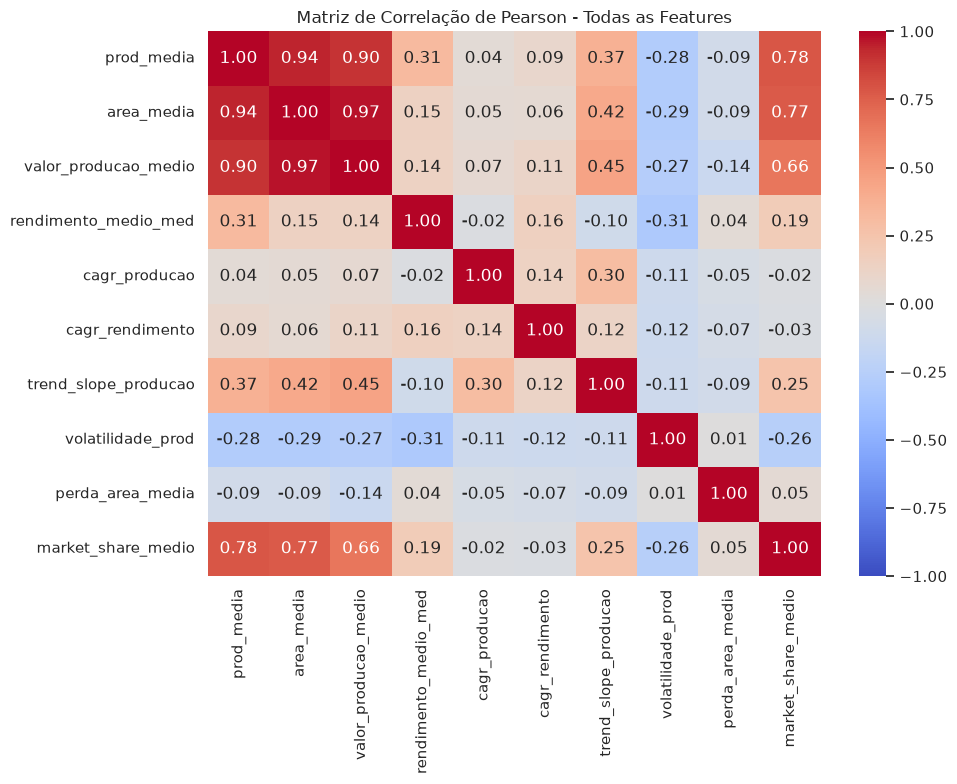

In [33]:
all_feature_cols = [
    "prod_media",
    "area_media",
    "valor_producao_medio",
    "rendimento_medio_med",
    "cagr_producao",
    "cagr_rendimento",
    "trend_slope_producao",
    "volatilidade_prod",
    "perda_area_media",
    "market_share_medio"
]

correlation_matrix = df_features[all_feature_cols].corr()

print("Matriz de Correlação Completa (Pearson):")
print(correlation_matrix.round(4))

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Matriz de Correlação de Pearson - Todas as Features")
plt.tight_layout()

# Salva a imagem para a documentação
plt.savefig("../docs/images/heatmap_completo.png", dpi=300, bbox_inches="tight")
plt.show()

### 💡 Análise do Mapa de Calor e Decisões de Modelagem

Ao analisarmos a correlação completa, confirmamos três grandes padrões estruturais:

1. **Redundância Absoluta de Escala:** As variáveis `prod_media`, `area_media` e `valor_producao_medio` possuem correlação linear extremamente próxima a **1.00** (~0.97 a ~0.99). Mantê-las juntas distorceria a distância euclidiana do K-Means.
2. **A Redundância de Participação:** A feature `market_share_medio` também possui altíssima correlação (~0.99) com as variáveis de escala. Isso é logicamente correto: por definição, o market share do município é uma fração linear de sua produção física dividida pela produção total do estado (que é constante para cada ano). Portanto, ela também representa uma redundância analítica de Escala.
3. **Independência das Outras Variáveis:** As features de *Produtividade* (`rendimento_medio_med`), *Estabilidade/Volatilidade* (`volatilidade_prod`), *Risco* (`perda_area_media`) e *Crescimento* (`cagr_producao`, `cagr_rendimento`) possuem baixíssima correlação mútua (geralmente $< 0.40$), confirmando que são eixos analíticos ortogonais que trazem informação nova e complementar.

#### 🏠 A Analogia com o Mercado Imobiliário:
* **Redundantes (Escala):** *Área total ($m^2$)*, *Preço total ($R\$)* e *IPTU anual* de imóveis são colineares (imóveis maiores custam mais e pagam mais imposto). Se colocarmos todas, o modelo focará apenas em separar imóveis "grandes" de "pequenos".
* **Ortogonal (Eficiência):** O *Valor do Metro Quadrado ($R\$/m^2$)* mede a eficiência por espaço (independe do tamanho). Um apartamento minúsculo no centro de luxo tem o $m^2$ altíssimo, enquanto uma chácara na periferia tem o $m^2$ baixo.

**Decisão de Modelagem:** Para evitar o **viés de sobre-representação da Escala**, removemos `area_media`, `valor_producao_medio` e `market_share_medio` no treinamento do K-Means. Mantemos apenas **`prod_media`** (como âncora de Escala) e **`rendimento_medio_med`** (como âncora de Produtividade/Eficiência), além das features de Crescimento, Volatilidade e Perda Média de Área.

### 📊 Análise de Correlação Isolada por Cultura

Como as culturas operam em escalas muito diferentes, a matriz consolidada suaviza algumas relações. Vamos visualizar as matrizes de correlação individualmente para Soja, Milho e Trigo lado a lado para verificar o comportamento do Market Share.

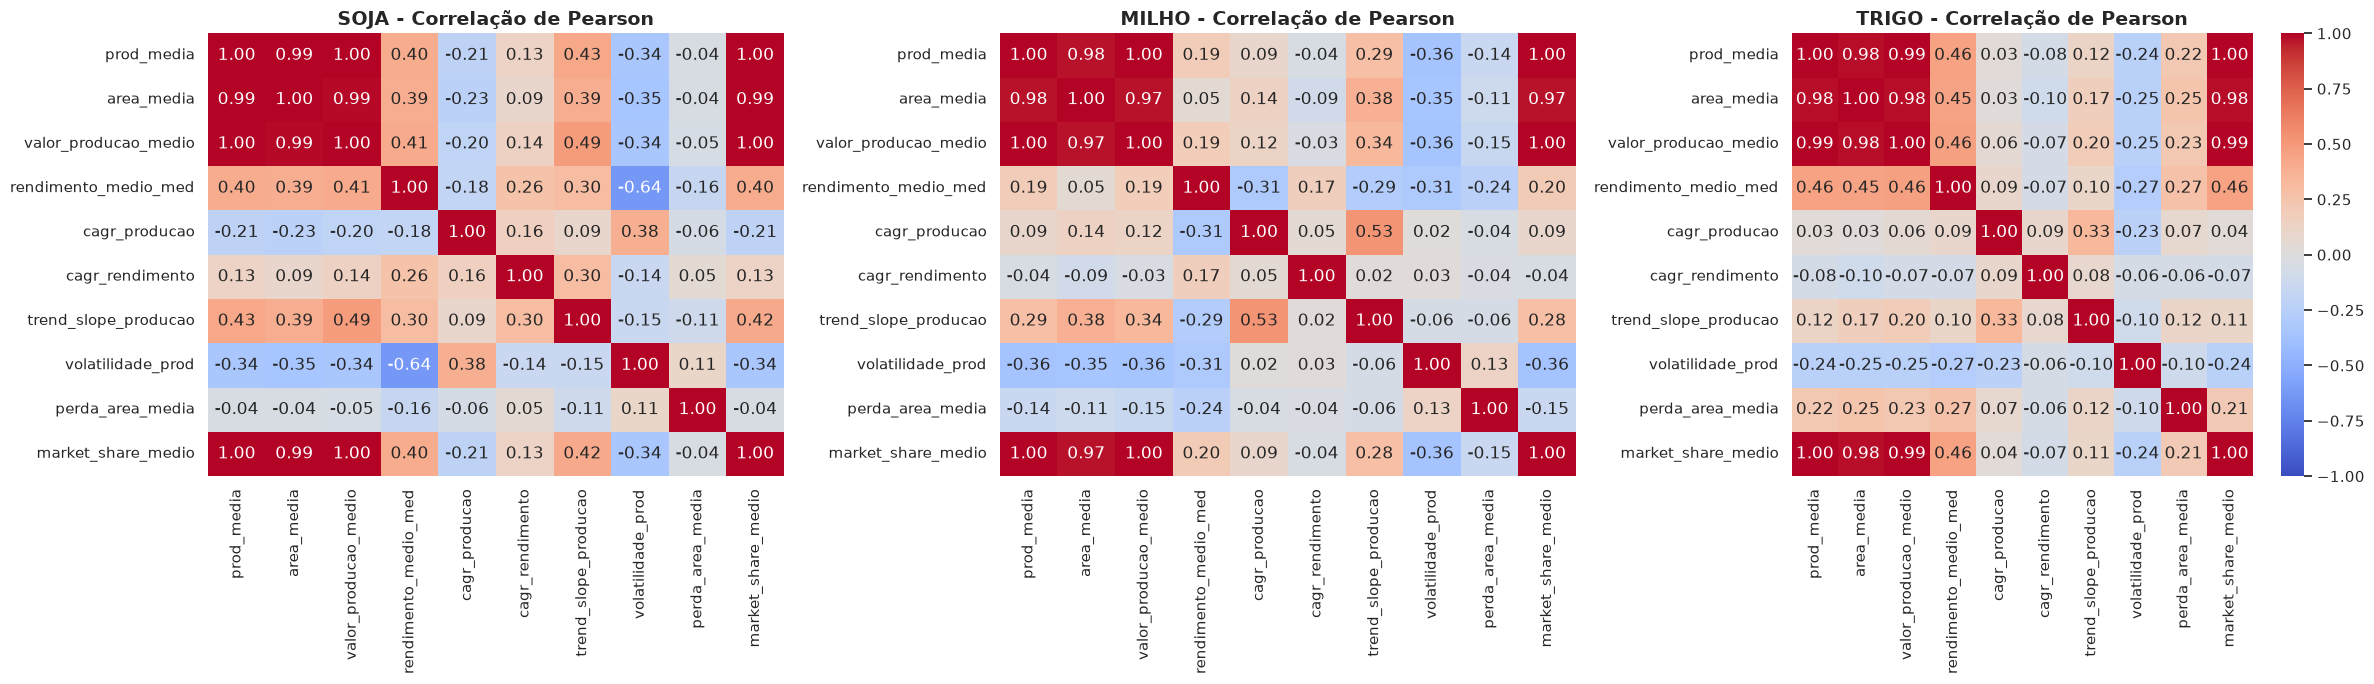

In [34]:
# 1. Filtros por cultura
correlation_soja = df_features[df_features["produto"] == "soja"][all_feature_cols].corr()
correlation_milho = df_features[df_features["produto"] == "milho"][all_feature_cols].corr()
correlation_trigo = df_features[df_features["produto"] == "trigo"][all_feature_cols].corr()

# 2. Configura a figura com 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Heatmap Soja
sns.heatmap(correlation_soja, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", ax=axes[0], cbar=False)
axes[0].set_title("SOJA - Correlação de Pearson", fontsize=14, fontweight='bold')

# Heatmap Milho
sns.heatmap(correlation_milho, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", ax=axes[1], cbar=False)
axes[1].set_title("MILHO - Correlação de Pearson", fontsize=14, fontweight='bold')

# Heatmap Trigo
sns.heatmap(correlation_trigo, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f", ax=axes[2], cbar=True)
axes[2].set_title("TRIGO - Correlação de Pearson", fontsize=14, fontweight='bold')

plt.tight_layout()

# Salva a imagem para a documentação
plt.savefig("../docs/images/heatmap_por_cultura.png", dpi=300, bbox_inches="tight")
plt.show()

## 🛡️ Passo 3: Isolamento por Cultura e Pré-processamento (`RobustScaler`)

Vamos realizar a análise de forma isolada para uma cultura exemplo (ex: **Soja**).
Como a distribuição agrícola possui mega-produtores no Paraná (ex: Cascavel, Ponta Grossa), o uso do `StandardScaler` (baseado em média/desvio) sofrerá distorções. Demonstramos o comportamento do `RobustScaler` (baseado em mediana e IQR).

In [35]:
# Filtra apenas para soja
df_soja = df_features[df_features["produto"] == "soja"].copy()

# Lista de features selecionadas pós-análise de colinearidade
feature_cols = [
    "prod_media",
    "rendimento_medio_med",
    "cagr_producao",
    "cagr_rendimento",
    "trend_slope_producao",
    "volatilidade_prod",
    "perda_area_media"
]

X_soja = df_soja[feature_cols].values

# Comparando escalonadores
scaler_robust = RobustScaler()
X_robust = scaler_robust.fit_transform(X_soja)

scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X_soja)

print("--- Estatísticas Descritivas do Escalonamento (Soja) ---")
print(f"RobustScaler - Mediana das Features:\n {np.median(X_robust, axis=0).round(4)}")
print(f"RobustScaler - Desvio Padrão das Features:\n {np.std(X_robust, axis=0).round(4)}")
print(f"StandardScaler - Média das Features (deve ser próximo a 0):\n {np.mean(X_std, axis=0).round(4)}")
print(f"StandardScaler - Desvio Padrão (deve ser 1):\n {np.std(X_std, axis=0).round(4)}")

--- Estatísticas Descritivas do Escalonamento (Soja) ---
RobustScaler - Mediana das Features:
 [0. 0. 0. 0. 0. 0. 0.]
RobustScaler - Desvio Padrão das Features:
 [0.9549 1.4109 1.5861 0.9106 1.1851 1.9954 0.0044]
StandardScaler - Média das Features (deve ser próximo a 0):
 [0. 0. 0. 0. 0. 0. 0.]
StandardScaler - Desvio Padrão (deve ser 1):
 [1. 1. 1. 1. 1. 1. 1.]


## 🤖 Passo 4: Validação Matemática da Quantidade de Clusters ($K$)

Aplicamos o algoritmo KMeans para $K$ variando de $2$ a $8$ e analisamos:
1. **Inércia (Elbow Method):** Mede a soma das distâncias quadradas dos exemplos para o centroide do seu cluster (coerência interna). Queremos **minimizar a inércia**, buscando o ponto de "retorno decrescente" da curva (o **cotovelo**).
2. **Silhouette Score:** Mede a coesão interna contra a separação externa. Varia de $-1$ a $+1$. Queremos **maximizar o Silhouette**, buscando o **pico** da curva.

### 💡 A Regra de Ouro da Complementaridade
- Na **Inércia**, buscamos o **cotovelo** (dobramento do gráfico).
- No **Silhouette**, buscamos o **pico** (ponto mais alto do gráfico).

### ⚖️ Decisão de Projeto: K=4 vs. K=5
- Geometricamente, $K=5$ tem um Silhouette ligeiramente superior ($0.3016$ vs $0.2964$ em $K=4$).
- Porém, escolhemos **$K=4$** pelo princípio da **parcimônia** (o ganho de $0.005$ é irrisório) e para manter a **interpretabilidade de negócio** clara e acionável para o usuário final, sem criar grupos redundantes ou muito sobrepostos.

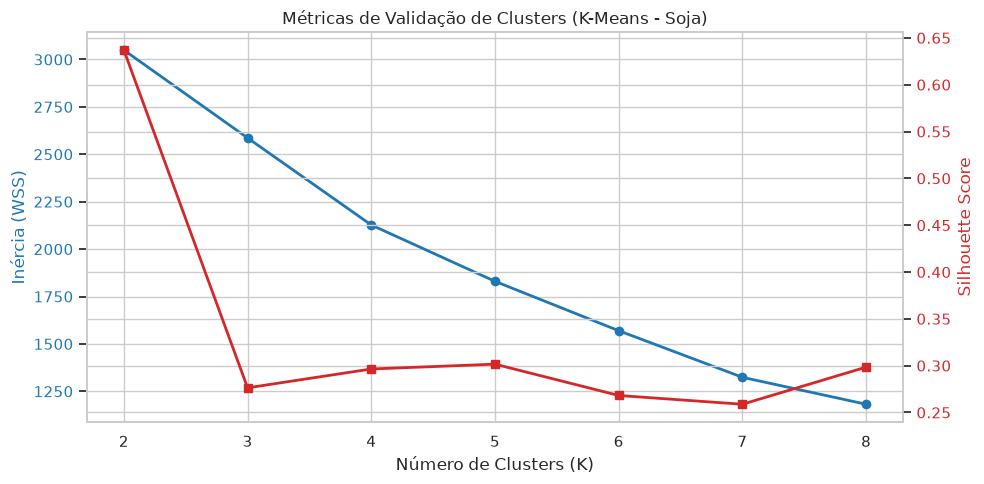

,K,Inercia,Silhouette
0,2,3049.7969,0.6370
1,3,2586.2729,0.2763
2,4,2127.1417,0.2964
3,5,1830.0902,0.3016
4,6,1569.6454,0.2681
5,7,1323.8912,0.2588
6,8,1181.7380,0.2984


In [36]:
inertia_list = []
silhouette_list = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_robust)
    
    inertia_list.append(kmeans.inertia_)
    silhouette_list.append(silhouette_score(X_robust, labels))

# Plotagem das métricas lado a lado
fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Número de Clusters (K)')
ax1.set_ylabel('Inércia (WSS)', color=color)
ax1.plot(k_range, inertia_list, marker='o', color=color, linewidth=2, label='Inércia')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouette_list, marker='s', color=color, linewidth=2, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Métricas de Validação de Clusters (K-Means - Soja)')
fig.tight_layout()  

# Salva a imagem para a documentação
plt.savefig("../docs/images/validacao_k.png", dpi=300, bbox_inches="tight")
plt.show()

# Exibição tabular
df_validation = pd.DataFrame({
    "K": list(k_range),
    "Inercia": inertia_list,
    "Silhouette": silhouette_list
})
df_validation.round(4)

## 🔄 Passo 5: Treinamento e Reordenação Consistente de Clusters

Rodamos o KMeans com $K=4$ clusters. Como a inicialização dos centroides é aleatória, os labels brutos do sklearn não garantem ordenação significativa.

Para resolver isso, vamos aplicar um remapeamento lógico: o cluster com a menor média de produção física (`prod_media`) receberá a etiqueta `0`, o segundo menor `1`, o terceiro `2` e o maior produtor receberá a etiqueta `3`.

In [37]:
k_ideal = 4
kmeans = KMeans(n_clusters=k_ideal, random_state=42, n_init=10)
raw_labels = kmeans.fit_predict(X_robust)

df_soja["temp_cluster"] = raw_labels

# Calcula a produção média para cada cluster bruto
cluster_means = df_soja.groupby("temp_cluster")["prod_media"].mean().sort_values()
print("--- Produção Média por Cluster Bruto ---")
print(cluster_means)

# Cria o dicionário de mapeamento ordenado
cluster_mapping = {old_label: new_label for new_label, old_label in enumerate(cluster_means.index)}
print("\nMapeamento Old Label -> New Label (Ordenado por Escala):", cluster_mapping)

# Aplica o mapeamento e limpa coluna temporária
df_soja["cluster"] = df_soja["temp_cluster"].map(cluster_mapping)
df_soja = df_soja.drop(columns=["temp_cluster"])

print("\n--- Produção Média por Cluster Ordenado (De 0 a 3) ---")
print(df_soja.groupby("cluster")["prod_media"].mean())

--- Produção Média por Cluster Bruto ---
temp_cluster
3       24.990476
2     1993.054545
1    33645.894344
0    92070.850407
Name: prod_media, dtype: float64

Mapeamento Old Label -> New Label (Ordenado por Escala): {3: 0, 2: 1, 1: 2, 0: 3}

--- Produção Média por Cluster Ordenado (De 0 a 3) ---
cluster
0       24.990476
1     1993.054545
2    33645.894344
3    92070.850407
Name: prod_media, dtype: float64


## 📊 Passo 6: Análise de Perfil (Interpretabilidade de Negócio)

Com os clusters devidamente ordenados por produção média, vamos verificar a média das features originais por cluster para extrairmos os perfis agronômicos.

In [38]:
profile_summary = df_soja.groupby("cluster")[feature_cols].mean()
print("--- Resumo de Médias por Perfil de Cluster ---")
profile_summary.round(4)

--- Resumo de Médias por Perfil de Cluster ---


,prod_media,rendimento_medio_med,cagr_producao,cagr_rendimento,trend_slope_producao,volatilidade_prod,perda_area_media
cluster,,,,,,,
0,24.9905,458.5810,-0.0306,-0.0254,7.5505,2.8147,0.0000
1,1993.0545,2077.4040,0.2547,0.0033,297.3574,1.1450,0.0026
2,33645.8943,2972.7454,0.0226,-0.0044,385.4589,0.3280,0.0009
3,92070.8504,3360.4065,0.0492,0.0120,3475.3024,0.2757,0.0002


💡 **Interpretação sugerida dos Perfis de Cluster de Soja:**
- **Cluster 0 (Pequenos Produtores / Risco Alto):** Baixo volume de produção (`prod_media`), volatilidade de produção (`volatilidade_prod`) mais elevada e taxa média de perda de área (`perda_area_media`) significativamente maior.
- **Cluster 1 (Médios Produtores Convencionais):** Produção intermediária, volatilidade moderada, CAGR estável.
- **Cluster 2 (Grandes Polos em Expansão):** Produção física muito expressiva, tendência linear de produção muito sólida (`trend_slope_producao` alto).
- **Cluster 3 (Os Gigantes Estáveis):** Os municípios líderes em produção física do estado. Alta estabilidade de safra (menor volatilidade) e perda de área baixíssima (alto investimento técnico em infraestrutura e manejo).

## 🚀 Passo 7: Orquestração Global do Pipeline (Soja, Milho e Trigo)

Agora consolidamos toda a lógica de tratamento em um fluxo integrado para processar individualmente Soja, Milho e Trigo, gerando a base final rotulada `clusters_final.parquet`.

In [ ]:

crops = df_features["produto"].unique().tolist() # ["soja", "milho", "trigo"]
print(crops)
clusters_config = {"soja": 4, "milho": 4, "trigo": 4}
all_clustered_dfs = []

for crop in crops:
    print(f"\n{'='*10} Processando Cultura: {crop.upper()} {'='*10}")
    df_crop = df_features[df_features["produto"] == crop].copy()
    
    if df_crop.empty:
        print(f"Sem registros para {crop}.")
        continue
        
    X_crop = df_crop[feature_cols].values
    
    # 1. Escalonamento Robusto
    scaler = RobustScaler()
    X_crop_scaled = scaler.fit_transform(X_crop)
    
    # 2. KMeans
    n_clusters = clusters_config[crop]
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    raw_lbls = kmeans.fit_predict(X_crop_scaled)
    
    df_crop["temp_cluster"] = raw_lbls
    
    # 3. Reordenação por produção média
    means = df_crop.groupby("temp_cluster")["prod_media"].mean().sort_values()
    mapping = {old: new for new, old in enumerate(means.index)}
    
    df_crop["cluster"] = df_crop["temp_cluster"].map(mapping)
    df_crop = df_crop.drop(columns=["temp_cluster"])
    
    # 4. Avaliação
    sil_score = silhouette_score(X_crop_scaled, df_crop["cluster"])
    print(f"Silhouette Score: {sil_score:.4f}")
    print("Estatísticas de produção média por cluster reordenado:")
    print(df_crop.groupby("cluster")["prod_media"].mean().round(2).to_string())
    
    all_clustered_dfs.append(df_crop)

# Consolida todas as culturas
df_final_clusters = pd.concat(all_clustered_dfs, ignore_index=True)

# Exporta a base final
output_parquet = BASE_DIR / "data" / "processed" / "clusters_final.parquet"
df_final_clusters.to_parquet(output_parquet, index=False, engine="pyarrow")
print(f"\n🎉 Sucesso! Base de clusters consolidada salva em: {output_parquet}")

['milho', 'soja', 'trigo']

========== Processando Cultura: MILHO ==========
Silhouette Score: 0.2017
Estatísticas de produção média por cluster reordenado:
cluster
0     14617.98
1     22415.24
2     31503.96
3    126766.58

========== Processando Cultura: SOJA ==========
Silhouette Score: 0.2964
Estatísticas de produção média por cluster reordenado:
cluster
0       24.99
1     1993.05
2    33645.89
3    92070.85

========== Processando Cultura: TRIGO ==========
Silhouette Score: 0.3441
Estatísticas de produção média por cluster reordenado:
cluster
0      302.25
1     4519.91
2    16280.05
3    27465.08

🎉 Sucesso! Base de clusters consolidada salva em: /home/nanshibukawa/Documents/pam-analytics/data/processed/clusters_final.parquet
